# Run CoTTA Adaptation (Sequential Protocol)
This notebook runs the sequential CTTA protocol: IDRiD -> APTOS -> IDRiD

The model adapts continuously without weight reset, measuring:
- Domain adaptation on APTOS
- Catastrophic forgetting when returning to IDRiD

**Resume support**: If the runtime disconnects, re-run this notebook.
It will automatically detect the last completed adaptation checkpoint and resume.
Checkpoints are saved after each domain transition and every epoch during training.

In [1]:
import torch
torch.cuda.empty_cache()

In [2]:
import sys, os; sys.path.insert(0, os.getcwd())
import os, sys
_d = os.getcwd()
PROJECT_ROOT = None
while _d != os.path.dirname(_d):
    if os.path.exists(os.path.join(_d, 'setup.py')):
        PROJECT_ROOT = _d
        break
    _d = os.path.dirname(_d)
if PROJECT_ROOT is None:
    for _p in ['/kaggle/working/medical_CTTA', '/content/medical_CTTA']:
        if os.path.isdir(_p):
            PROJECT_ROOT = _p
            break
if PROJECT_ROOT and PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

from src.env import init
init()

from src.config import load_config
from src.utils.checkpointing import find_latest_adaptation_checkpoint

In [3]:
# Load config
config = load_config('configs/method/cotta.yaml')

print('Sequential CTTA Protocol:')
print(f'  Source: {config.sequential_ctta.source_domain.dataset.name}')
for i, td in enumerate(config.sequential_ctta.target_domains):
    print(f'  Target {i+1}: {td.dataset.name} - {td.description}')

# Check for resume
adapt_ckpt = find_latest_adaptation_checkpoint(config.output_dir)
if adapt_ckpt:
    print(f'\nResume checkpoint found: {adapt_ckpt}')
    print('Runner will resume from last completed domain.')

# HuggingFace token (needed for RETFound gated weights)
if not os.environ.get('HF_TOKEN'):
    import getpass
    token = getpass.getpass('Enter your HuggingFace token (hf_...): ')
    os.environ['HF_TOKEN'] = token
    print('✓ HF_TOKEN set')

Sequential CTTA Protocol:
  Source: idrid
  Target 1: aptos2019 - Target domain 1: heterogeneous multi-site (APTOS 2019)
  Target 2: idrid - Target domain 2: return to source domain (test forgetting)
✓ HF_TOKEN set


In [4]:
# Run sequential CTTA (runner handles resume internally)
from src.evaluation.runner import CTTARunner

runner = CTTARunner(config)
results = runner.run()

2026-07-13 17:47:23,818 - src.evaluation.runner - INFO - Starting sequential CTTA experiment
2026-07-13 17:47:23,819 - src.evaluation.runner - INFO - Source: Source domain: single camera, single clinic (IDRiD)
2026-07-13 17:47:23,820 - src.evaluation.runner - INFO - Target 1: Target domain 1: heterogeneous multi-site (APTOS 2019)
2026-07-13 17:47:23,820 - src.evaluation.runner - INFO - Target 2: Target domain 2: return to source domain (test forgetting)
2026-07-13 17:47:28,690 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/YukunZhou/RETFound_mae_natureCFP/resolve/main/RETFound_mae_natureCFP.pth "HTTP/1.1 302 Found"
2026-07-13 17:47:32,915 - src.evaluation.runner - INFO - Loading shared source model from outputs/shared_source
2026-07-13 17:47:38,915 - src.evaluation.runner - INFO - Evaluating source baseline
2026-07-13 17:47:46,583 - src.evaluation.runner - INFO - 
2026-07-13 17:47:46,585 - src.evaluation.runner - INFO - Adapting to target domain 1: Target domain 1: heteroge

Adapting to aptos2019:   0%|          | 0/22 [00:00<?, ?it/s]

2026-07-13 17:49:04,309 - src.evaluation.runner - INFO -   Shift detected at batch 0
2026-07-13 17:49:11,636 - src.evaluation.runner - INFO -   Adapt step batch 0: loss=1.1054, conf_samples=14, mean_max_prob=0.3650


Adapting to aptos2019:   5%|▍         | 1/22 [00:11<03:51, 11.03s/it, acc=0.3125, adaptations=1]

2026-07-13 17:49:13,333 - src.evaluation.runner - INFO -   Shift detected at batch 1
2026-07-13 17:49:19,828 - src.evaluation.runner - INFO -   Adapt step batch 1: loss=1.0361, conf_samples=14, mean_max_prob=0.3980


...

Adapting to idrid:  17%|█▋        | 1/6 [00:10<00:54, 10.92s/it, acc=0.3125, adaptations=1]

2026-07-13 17:53:41,796 - src.evaluation.runner - INFO -   Shift detected at batch 1
2026-07-13 17:53:48,172 - src.evaluation.runner - INFO -   Adapt step batch 1: loss=1.0429, conf_samples=15, mean_max_prob=0.3640


Adapting to idrid: 100%|██████████| 6/6 [00:25<00:00,  4.28s/it, acc=0.3125, adaptations=2]

2026-07-13 17:53:55,447 - src.evaluation.runner - INFO - Evaluating after adaptation on idrid


2026-07-13 17:54:05,814 - src.evaluation.runner - INFO - Post-adaptation QWK: 0.6432
2026-07-13 17:54:05,816 - src.evaluation.runner - INFO - Adaptations: 2/6
2026-07-13 17:54:09,375 - src.evaluation.runner - INFO - Forgetting (source -> ... -> source): 0.0060
2026-07-13 17:54:09,377 - src.evaluation.runner - INFO - Domain aptos2019: baseline QWK=0.3866, post QWK=0.3821
2026-07-13 17:54:09,378 - src.evaluation.runner - INFO - Domain idrid: baseline QWK=0.6432, post QWK=0.6432
2026-07-13 17:54:09,383 - src.evaluation.runner - INFO - Results saved to outputs/cotta/ctta_results.json


In [ ]:
# Print summary
print('\n=== Sequential CTTA Results ===')
print(f'Source baseline QWK: {results["source_baseline"]["qwk"]:.4f}')

for dr in results['domain_results']:
    print(f'\nDomain: {dr["domain_name"]} - {dr["description"]}')
    print(f'  Baseline QWK: {dr["baseline_metrics"]["qwk"]:.4f}')
    print(f'  Post-adapt QWK: {dr["post_adaptation_metrics"]["qwk"]:.4f}')
    print(f'  Adaptations: {dr["num_adaptations"]}/{dr["total_batches"]}')

if 'forgetting' in results:
    print(f'\nForgetting (source -> ... -> source): {results["forgetting"]:.4f}')
    
if 'adaptation_rate' in results:
    print(f'Overall adaptation rate: {results["adaptation_rate"]:.4f}')


=== Sequential CTTA Results ===
Source baseline QWK: 0.6492

Domain: aptos2019 - Target domain 1: heterogeneous multi-site (APTOS 2019)
  Baseline QWK: 0.3866
  Post-adapt QWK: 0.3821
  Adaptations: 22/22

Domain: idrid - Target domain 2: return to source domain (test forgetting)
  Baseline QWK: 0.6432
  Post-adapt QWK: 0.6432
  Adaptations: 2/6

Forgetting (source -> ... -> source): 0.0060
Overall adaptation rate: 0.8571


No training metrics found.


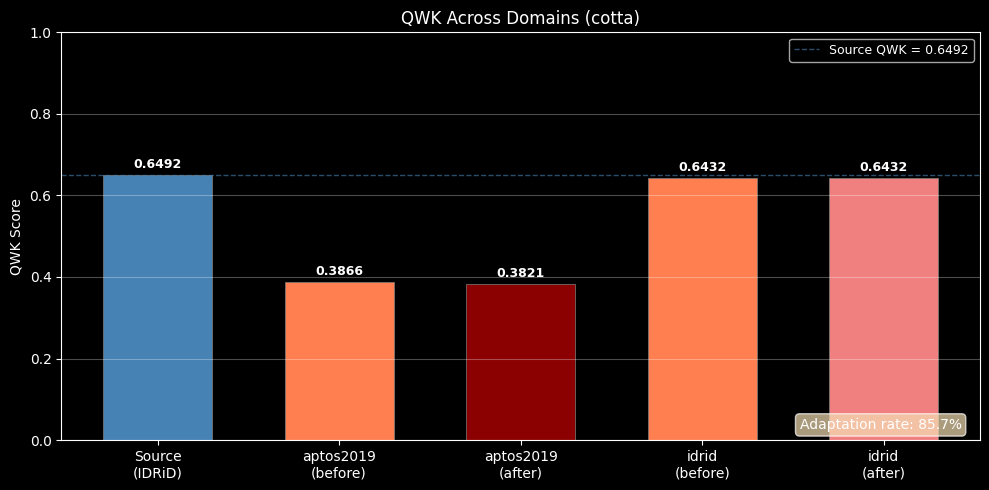

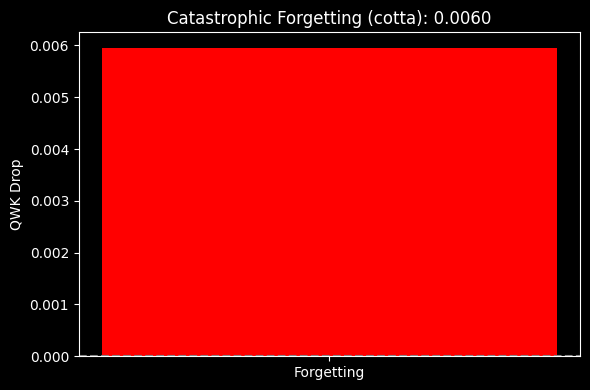

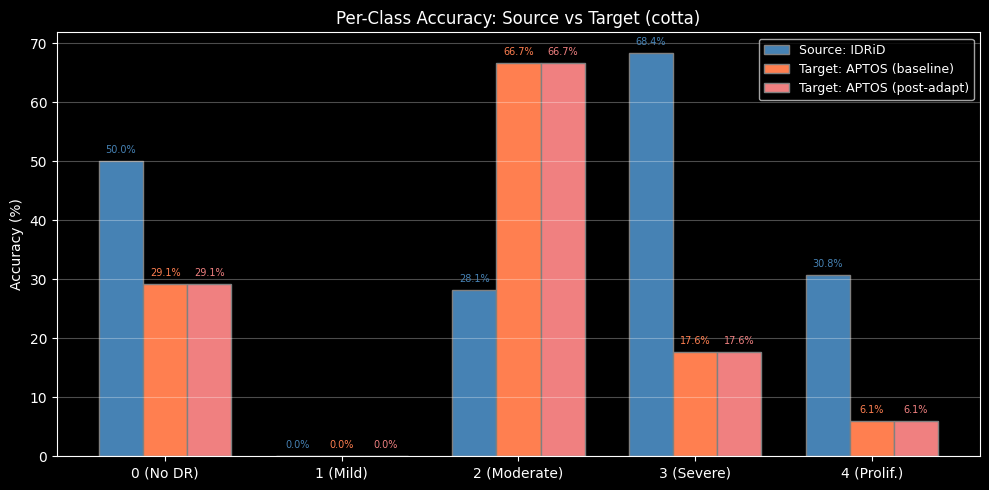

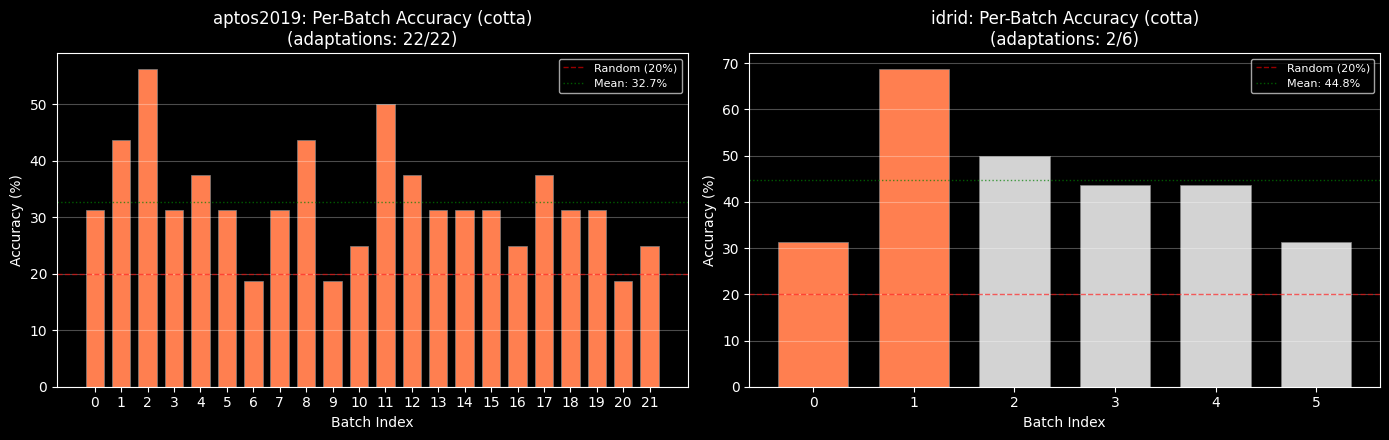

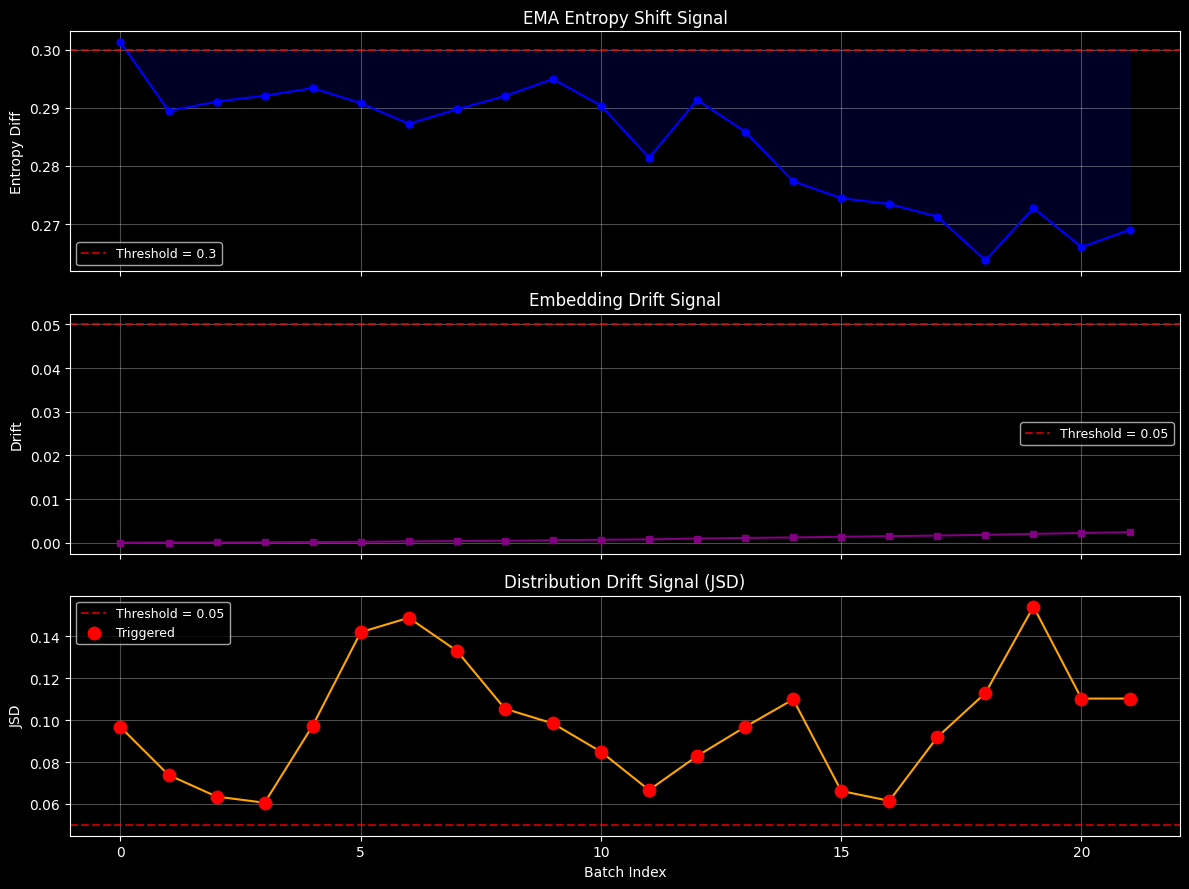

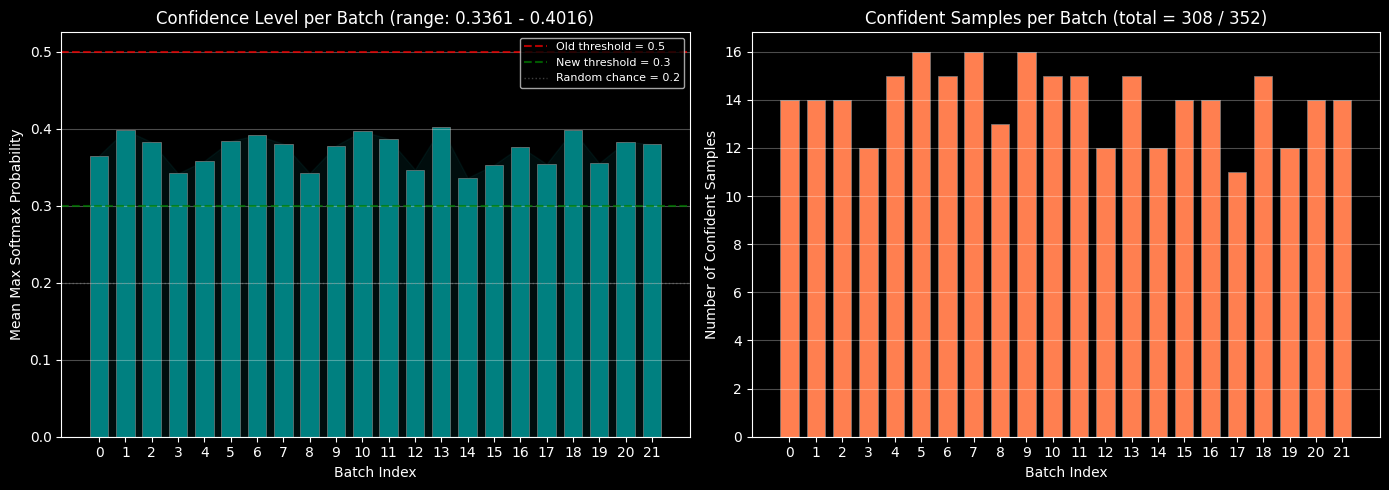

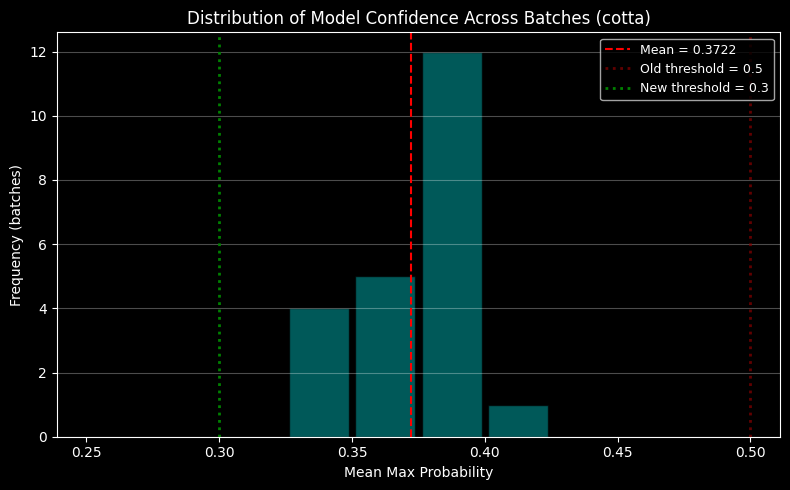

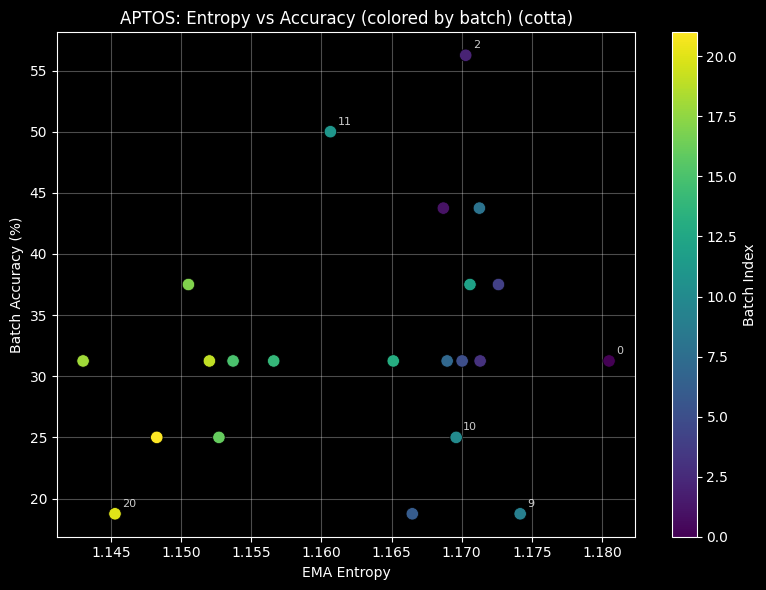

================ Sequential CTTA Results (cotta) ================
Source baseline QWK: 0.6492

--- aptos2019 ---
  Baseline QWK:       0.3866
  Post-adapt QWK:     0.3821
  Adaptations:        22/22
  Mean batch acc:     32.7%
  Conf samples:       308 / 352
  Total loss:         19.4161

--- idrid ---
  Baseline QWK:       0.6432
  Post-adapt QWK:     0.6432
  Adaptations:        2/6
  Mean batch acc:     44.8%
  Conf samples:       30 / 32
  Total loss:         2.1575

Forgetting:           0.005955557180886695
Adaptation rate:      85.71%


In [6]:
# --- Visualization ---
from src.viz import (
    get_domain_data, plot_training_metrics, plot_qwk_bar, plot_forgetting,
    plot_per_class_accuracy, plot_per_batch_accuracy,
    plot_adaptation_metrics, plot_confidence_distribution,
    plot_entropy_vs_accuracy, print_summary_table,
)
from src.viz.cotta import plot_shift_detection_signals

import json
from pathlib import Path

plots_dir = Path(config.output_dir) / 'plots'
plots_dir.mkdir(exist_ok=True)

with open(Path(config.output_dir) / 'ctta_results.json') as f:
    results = json.load(f)

aptos_dr, idrid_dr, aptos_steps, aptos_batches = get_domain_data(results)
method = results.get("method", "")

plot_training_metrics(config, plots_dir)
plot_qwk_bar(results, plots_dir, method_name=method)
plot_forgetting(results, plots_dir, method_name=method)
plot_per_class_accuracy(results, aptos_dr, plots_dir, method_name=method)
plot_per_batch_accuracy(aptos_dr, idrid_dr, plots_dir, method_name=method)
plot_shift_detection_signals(aptos_steps, plots_dir)
plot_adaptation_metrics(aptos_steps, plots_dir)
plot_confidence_distribution(aptos_steps, plots_dir, method_name=method)
plot_entropy_vs_accuracy(aptos_steps, aptos_batches, plots_dir, method_name=method)
print_summary_table(results, method_name=method)